In [1]:
import sys
sys.path.insert(1, '../src/')
from RipUOT import RipUOT
import torch
import numpy as np

/opt/anaconda3/envs/CRUOT_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 1
np.random.seed(1) 
torch.manual_seed(1)
torch.use_deterministic_algorithms(True)

scGM dataset.

In [3]:
x_s_np = np.load("../datasets/scGM/X_scGM.npy")
x_s_np = np.float64(x_s_np)
# -------------------------------
x_s_np = x_s_np - x_s_np.mean(axis=0)
row_maxnorm_expr = np.max(np.linalg.norm(x_s_np, axis=1, keepdims=True))
x_s_np = x_s_np / row_maxnorm_expr
# -------------------------------
x_s = torch.tensor(x_s_np, dtype=torch.float64)

x_t_np = np.load("../datasets/scGM/Y_scGM.npy")
x_t_np = np.float64(x_t_np)
# -------------------------------
row_maxnorm_methy = np.max(np.linalg.norm(x_t_np, axis=1, keepdims=True))
x_t_np = x_t_np / row_maxnorm_methy
# -------------------------------
x_t = torch.tensor(x_t_np, dtype=torch.float64)

type_expr = np.loadtxt("/Users/emapardini/Desktop/Github Projects/master-thesis/codes/datasets/scGM/scGM_typeExpression.txt")
type_expr = type_expr.astype(np.int64)

type_methy = np.loadtxt("/Users/emapardini/Desktop/Github Projects/master-thesis/codes/datasets/scGM/scGM_typeMethylation.txt")
type_methy = type_methy.astype(np.int64)

In [4]:
device = torch.device("cpu")

x_s = x_s.to(device)
x_t = x_t.to(device)

In [5]:
ripuot = RipUOT(x_s, x_t, lambd=1.3, lambd_2=None, eps=5e-3, log=False)
ripuot.fit(k_cost=1.0, max_iter=100, tol=1e-6, max_iter_sinkhorn=10000, tol_sinkhorn=1e-6, device=device, verbose=True, log=False)

1
Sinkhorn stopped at iteration 1005 with error 9.940373722483464e-07
Mean f: -0.007398455243099039 Mean g: -0.016183259632678682
error M: tensor(1.0576, dtype=torch.float64)
error P: tensor(0.0095, dtype=torch.float64)
2
Sinkhorn stopped at iteration 934 with error 9.941043701000574e-07
Mean f: -0.048779318655983214 Mean g: -0.06727764978399857
error M: tensor(0.3487, dtype=torch.float64)
error P: tensor(0.0122, dtype=torch.float64)
3
Sinkhorn stopped at iteration 665 with error 9.9846670122139e-07
Mean f: -0.06434264973035303 Mean g: -0.07379392767637094
error M: tensor(0.1299, dtype=torch.float64)
error P: tensor(0.0069, dtype=torch.float64)
4
Sinkhorn stopped at iteration 448 with error 9.986820160984289e-07
Mean f: -0.06950573317257272 Mean g: -0.0748167929369442
error M: tensor(0.0764, dtype=torch.float64)
error P: tensor(0.0038, dtype=torch.float64)
5
Sinkhorn stopped at iteration 363 with error 9.973795817184037e-07
Mean f: -0.0719245844220868 Mean g: -0.07514290647440619
error

In [6]:
X_s, X_t = ripuot.align(eps_1=5e-4, max_iter_sinkhorn=10000, tol_sinkhorn=1e-6)

Sinkhorn stopped at iteration 3570 with error 9.994781953737153e-07
Mean f: 0.028135838613712133 Mean g: -0.18605301681463018


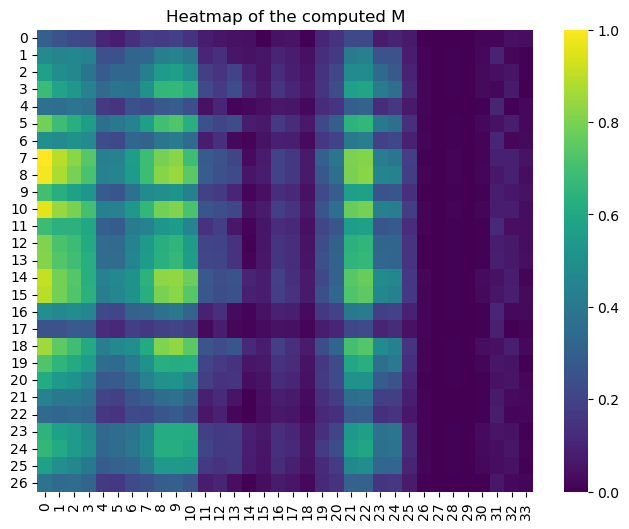

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

M_abs_np = ripuot.M.abs().cpu().numpy()
M_map_np = M_abs_np / M_abs_np.max()
plt.figure(figsize=(8, 6))
sns.heatmap(M_map_np, cmap="viridis", annot=False)
plt.title("Heatmap of the computed M")
plt.show()

In [8]:
import evals 

lta = evals.compute_lta(X_s.numpy(), X_t.numpy(), type_expr, type_methy, n=5)

print("LTA:", lta)

LTA: 0.6892655367231638


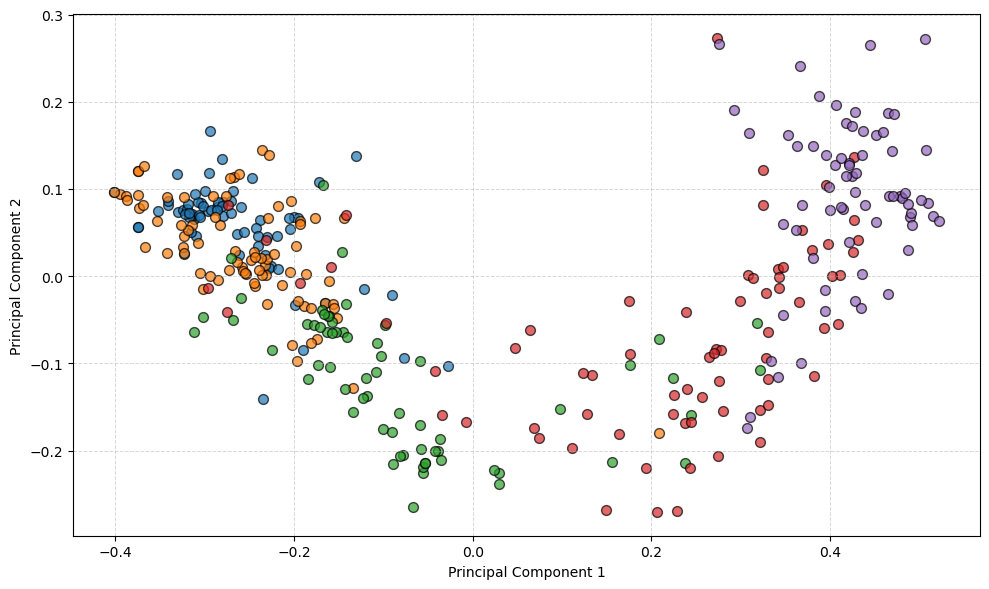

In [9]:
evals.plot_projection(
    source_proj=X_s.numpy(),    # your projected source domain (n_samples, d)
    source_labels=type_expr,    # true source labels (1D array)
    target_data=X_t.numpy(),    # your original target domain (n_samples, d)
    target_labels=type_methy,   # true target labels (1D array)
    method='pca',               # or 'umap'
    save_pdf=True
)